<img src="./assets/ga-logo.png" style="float: left; margin: 20px; height: 55px">

# Handling Missing Data in Python

---

### About
In this notebook, we will explore various techniques for identifying, visualizing, and handling missing data in Python using `pandas` and other libraries. Missing data is a common challenge in real-world data sets, and understanding how to address it effectively is a crucial skill for data analysis.

### Learning Objectives
- Identify and visualize missing data
- Understand patterns of missingness
- Implement deletion methods
- Apply simple imputation techniques
- Evaluate the impact of different approaches

### Notebook Guide
1. Setup and Load Data
2. Identifying Missing Data
3. Deletion Methods
4. Simple Imputation Methods
5. Imputation Based on Other Variables
6. Handling Mixed Data Types
7. Best Practices and Conclusion
8. Now You Try
9. Conclusion

# 1. Setup and Load Data

In [6]:
!pip install missingno
!pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 23.4 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [7]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# For visualization of missing data
import missingno as msno

# For evaluation
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Set the random seed for reproducibility
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style="whitegrid")

Let's load a data set with missing values to work with. We'll use a modified version of the Titanic data set.

In [8]:
# Load the Titanic data set
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
titanic_df = pd.read_csv(url)
titanic_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


# 2. Identifying Missing Data

The first step in handling missing data is to identify and understand the extent of missingness in your data set.

In [12]:
# Check for missing values in each column
titanic_df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [14]:
# Calculate the percentage of missing values in each column
titanic_df.isnull().mean()

PassengerId    0.000000
Survived       0.000000
Pclass         0.000000
Name           0.000000
Sex            0.000000
Age            0.198653
SibSp          0.000000
Parch          0.000000
Ticket         0.000000
Fare           0.000000
Cabin          0.771044
Embarked       0.002245
dtype: float64

### Visualizing Missing Data

Visualization can help identify patterns in missingness. The [`missingno`](https://github.com/ResidentMario/missingno) library is particularly useful for this purpose.

<Axes: >

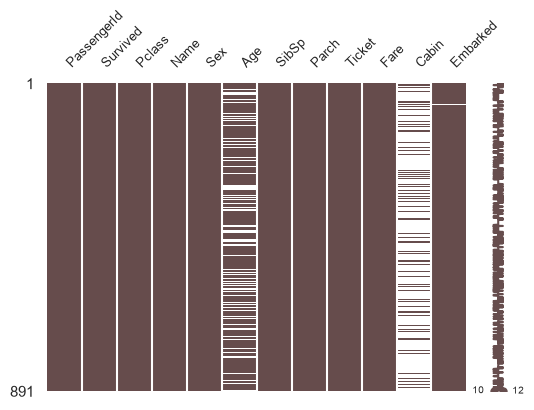

In [23]:
# Create a matrix visualization of missing values
msno.matrix(titanic_df,figsize = (6,4),fontsize = 9,color=(0.4, 0.3, 0.3))

<Axes: >

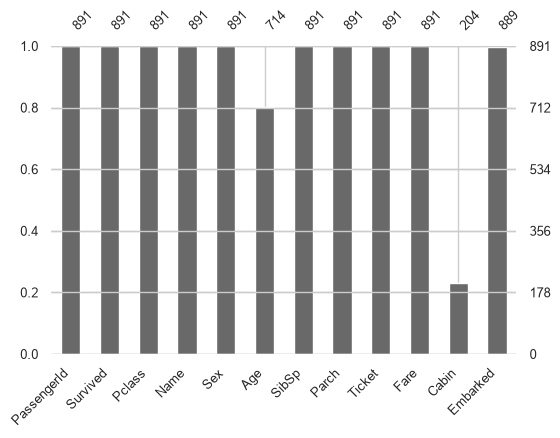

In [17]:
# Create a bar chart showing the count of missing values by column
msno.bar(titanic_df,figsize = (6,4), fontsize = 9)

Text(0.5, 1.0, 'correlation of missing values')

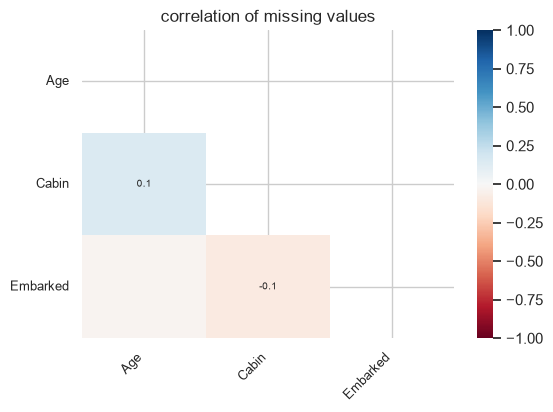

In [25]:
# Create a heatmap to show correlations between missingness
msno.heatmap(titanic_df,figsize=(6,4),fontsize=9)
plt.title("correlation of missing values")

### What patterns of missingness can you see in the Titanic data set? Are there any relationships between missing values in different columns?

There are several patterns of missingness:

1. The `Cabin` column has the highest percentage of missing values (78%), which suggests that cabin information was not recorded for most passengers.
2. `Age` is missing for about 20% of passengers, which is a substantial proportion.
3. `Embarked` has a very small percentage of missing values (0.2%), indicating just a few missing entries.

From the heatmap, there doesn't appear to be a strong correlation between missingness in different columns. This suggests that missingness in one column is not strongly related to missingness in other columns. For example, a passenger with a missing `Age` value is not necessarily more likely to have a missing `Cabin` value.

The lack of strong correlation between missingness patterns could suggest that the data might be **Missing Completely At Random (MCAR)** or **Missing At Random (MAR)**, but we would need _domain knowledge_ to confirm this.

# 3. Deletion Methods

The simplest approach to handling missing data is to remove observations or variables with missing values.

### 3.1 Listwise Deletion (Complete-case analysis)

- Listwise deletion (also known as complete-case analysis) is a method for handling missing data where an `entire row (case) is deleted if it is missing a value in any of the analyzed variables`.

In [32]:
# Remove all rows with any missing values
df_complete = titanic_df.dropna()
# Check how many rows remain
print(f"Original data set size : {len(titanic_df)}")
print(f"Original data set size : {len(df_complete)}")
print(f"Percentage of data retained: {len(df_complete) / len(titanic_df)* 100}%")

Original data set size : 891
Original data set size : 183
Percentage of data retained: 20.53872053872054%


### 3.2 Column Deletion

In [33]:
# Create a copy of the original data set
df_column_deletion = titanic_df.copy()
# Remove columns with more than 30% missing values
threshold = 0.3
df_column_deletion = df_column_deletion.loc[:,df_column_deletion.isnull().mean() < threshold]
# Print the remaining columns
print(f"Original columns: {titanic_df.columns.tolist()}")
print(f"Original columns: {df_column_deletion.columns.tolist()}")

Original columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
Original columns: ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Embarked']


### 3.3 Dropping specific columns

Sometimes, we decide to drop specific columns based on domain knowledge or analysis requirements.

In [ ]:
# Drop the 'Cabin' column


### 3.4 Dropping specific rows (subset of columns)

In [ ]:
# Drop rows where 'Age' is missing, but keep rows with missing values in other columns
# Check how many rows remain


### What are the advantages and disadvantages of the deletion methods you've implemented above?

**Advantages of deletion methods:**

1. **Simplicity**: Deletion methods are straightforward to understand and implement.
2. **No imputation bias**: By removing missing values rather than imputing them, we avoid introducing potential biases from imputation.
3. **Valid for MCAR data**: If data is Missing Completely At Random, listwise deletion produces unbiased parameter estimates (though with reduced efficiency).
4. **Computational efficiency**: Deletion methods require less computational resources than some imputation techniques.

**Disadvantages of deletion methods:**

1. **Data loss**: As seen in our implementation, listwise deletion resulted in losing about 80% of the data set, which is a significant reduction in sample size.
2. **Statistical power reduction**: Smaller sample sizes lead to reduced statistical power, making it harder to detect significant effects.
3. **Potential bias**: If data is not MCAR, deletion methods can introduce bias in the analysis.
    -  **Safe (MCAR)**:
        -  A page of a survey accidentally blew away in the wind. The missingness is pure luck/chance.
        -  A lab technician accidentally drops a vial of blood, smashing it on the floor. The patient's lab results are missing entirely due to an unpredictable accident.
    -  **Unsafe (Bias)**:
        - High-income earners intentionally skipped the Income question. Deleting them skews your average income downward
        - Patients drop out of the trial and miss their follow-up appointments because the drug's side effects are making them feel too sick to travel. Deleting these patients makes the drug look much safer than it actually is.
5. **Information loss**: Deleted observations might contain valuable information for other variables that are not missing.
6. **Complete-case analysis bias**: When certain groups or demographics are more likely to have missing data, their underrepresentation in the analysis could lead to skewed results.

**Specific to column deletion:**
- **Loss of potentially important variables**: In the Titanic data set, dropping the 'Cabin' column might eliminate information that could be useful for predicting survival (e.g., cabin location might correlate with survival rates).

**Specific to subset deletion:**
- **Inconsistent sample size**: Using different subsets of the data for different analyses can lead to inconsistencies in results.
- **Selective analysis**: Analyzing only passengers with age information might introduce selection bias if age missingness is related to other variables.

# 4. Simple Imputation Methods

Instead of deleting data, we can replace missing values with estimates.

### 4.1 Mean/Median/Mode Imputation

In [34]:
# Create a copy of the original data set
df_mean_imputed = titanic_df.copy()
# Impute missing values in the 'Age' column with the mean
mean_age = df_mean_imputed["Age"].mean()
df_mean_imputed["Age"] = df_mean_imputed["Age"].fillna(mean_age)
# Check that there are no missing values in the 'Age' column
print(f"Missing Value in Age: {df_mean_imputed["Age"].isnull().sum()}")

Missing Value in Age: 0


In [35]:
# Create a copy of the original data set
df_median_imputed = titanic_df.copy()
# Impute missing values in the 'Age' column with the median
median_age = df_median_imputed["Age"].median()
df_median_imputed["Age"] = df_median_imputed["Age"].fillna(median_age)
# Check that there are no missing values in the 'Age' column
print(f"Missing Value in Age: {df_median_imputed["Age"].isnull().sum()}")

Missing Value in Age: 0


Let's compare the distribution of `Age` before and after imputation.

> code below will generate the next output chart. for your reference

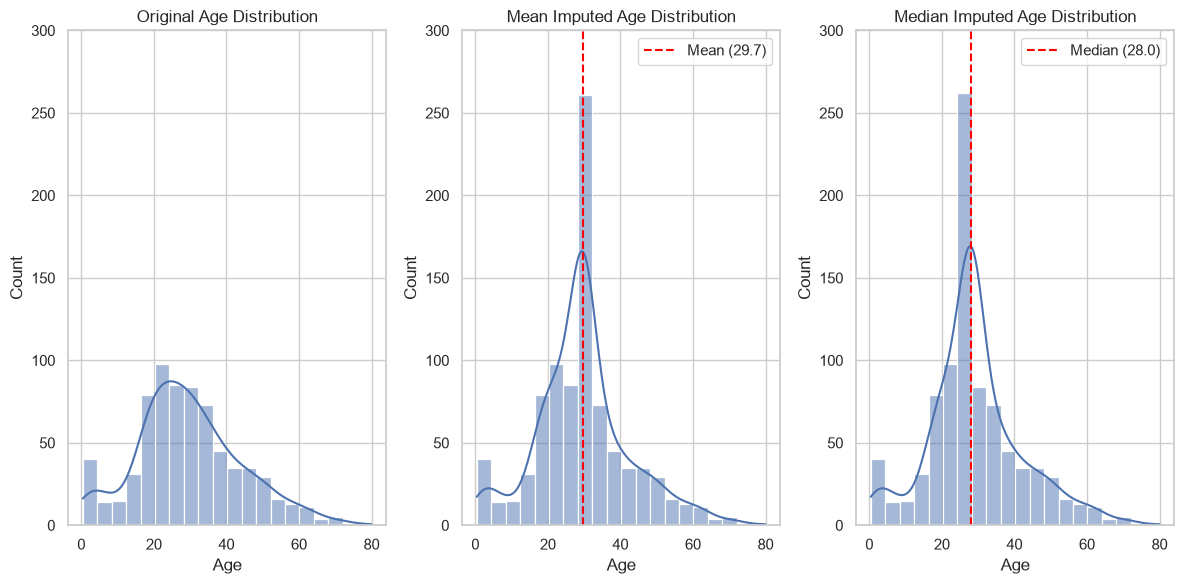

In [36]:
# Compare the original and imputed age distributions
plt.figure(figsize=(12, 6))

# Original age distribution (excluding missing values)
plt.subplot(1, 3, 1)
sns.histplot(titanic_df['Age'].dropna(), kde=True,bins=20)
plt.title('Original Age Distribution')
plt.xlabel('Age')
plt.ylim(0, 300)

# Mean imputed age distribution
plt.subplot(1, 3, 2)
sns.histplot(df_mean_imputed['Age'], kde=True,bins=20)
plt.axvline(mean_age, color='red', linestyle='--', label=f'Mean ({mean_age:.1f})')
plt.title('Mean Imputed Age Distribution')
plt.xlabel('Age')
plt.legend()
plt.ylim(0, 300)

# Median imputed age distribution
plt.subplot(1, 3, 3)
sns.histplot(df_median_imputed['Age'], kde=True,bins=20)
plt.axvline(median_age, color='red', linestyle='--', label=f'Median ({median_age:.1f})')
plt.title('Median Imputed Age Distribution')
plt.xlabel('Age')
plt.legend()
plt.ylim(0, 300)

plt.tight_layout()
plt.show()


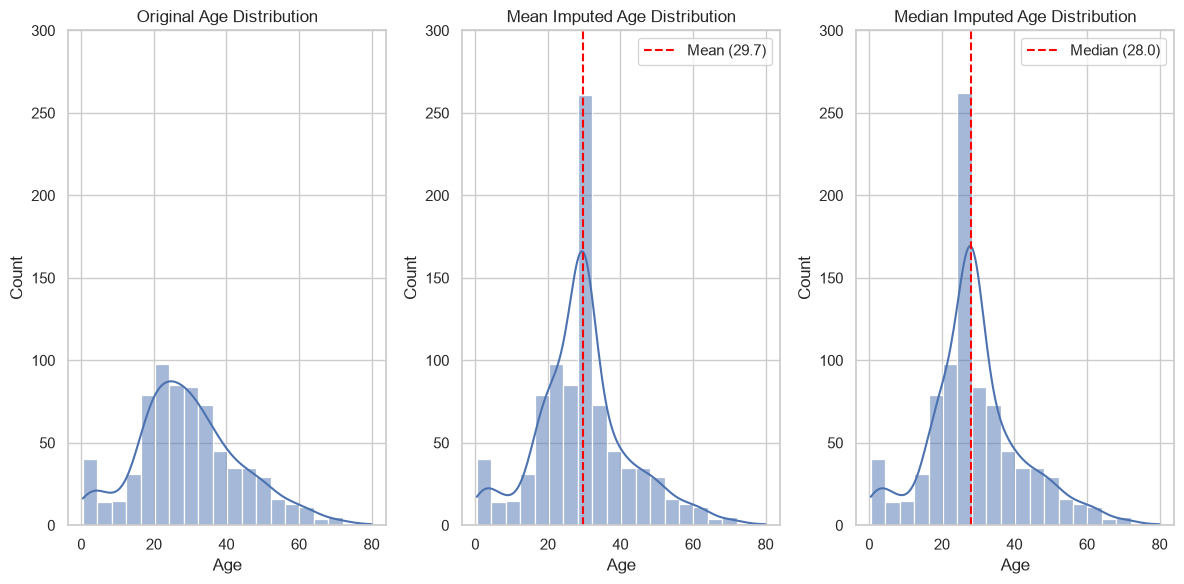

- Fill `Embarked` with mode

In [37]:
# get Embarked value_counts() to show values in that column
titanic_df["Embarked"].value_counts()


Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

In [38]:
# Create a copy of the original data set
df_mode_imputed = titanic_df.copy()
# Impute missing values in the 'Embarked' column with the mode
mode_age = df_median_imputed["Embarked"].mode()
df_mode_imputed["Embarked"] = df_mode_imputed["Embarked"].fillna(mode_age)
# Check that there are no missing values in the 'Embarked' column
print(f"Missing Value in Age: {df_mode_imputed["Embarked"].isnull().sum()}")

Missing Value in Age: 2


### 4.2 Constant Value Imputation

In [39]:
# Create a copy of the original data set
df_constant = titanic_df.copy()
# Impute missing 'Cabin' values with 'Unknown'
df_constant["Cabin"] = df_constant["Cabin"].fillna("unkown")
# Check the result
df_constant["Cabin"].value_counts()

Cabin
unkown         687
G6               4
C23 C25 C27      4
B96 B98          4
F33              3
              ... 
E17              1
A24              1
C50              1
B42              1
C148             1
Name: count, Length: 148, dtype: int64

### How do mean/median/mode imputation and constant imputation affect the distribution of the data? What are potential issues with these methods?

**Effects on data distribution:**

1. **Mean/Median Imputation**:
   - Creates an artificial spike in the distribution at the imputed value (mean or median)
   - Reduces variance as all missing values receive the same value
   - Distorts the natural shape of the distribution
   - Preserves the mean (in mean imputation) but alters other statistical properties

2. **Mode Imputation** (for categorical variables):
   - Increases the frequency of the already most common category
   - May artificially strengthen the majority class in classification problems
   - Can distort relationships between categorical variables

3. **Constant Imputation**:
   - Creates an artificial category or value that didn't exist in the original data
   - Introduces a distinct group of observations with the same imputed value
   - Can create meaningful separation if missingness itself is informative

**Potential issues with these methods:**

1. **Underestimation of variance and standard errors**:
   - Single imputation methods (filling all missing rows with the column mean, median) treat imputed values as known with certainty
       - `Example1`: When you fill a missing data gap with a single calculated number (e.g., you notice a missing value in a Lego set's price column and fill it with the average price of \\$50), Python and your statistical models don't know that \\$50 was a guess.The software treats that $50 as an absolute, 100% accurate fact collected from the real world, identical to the data points you actually measured
       - `Example2`: Imagine measuring the outdoor temperature for a week. You miss 3 days of measurements due to a broken sensor.
       - **Reality**: Those 3 missing days had natural fluctuations (maybe 15°C, 28°C, and 22°C).
       - **Single Imputation Fix**: You fill all 3 missing slots with the weekly average of 20°C.
       - **The Flaw**: Your dataset now looks like a flat line of 20°C values in the middle. The true day-to-day volatility (variance) of the weather has been systematically erased
   - Understates the uncertainty in the data, leading to overly confident statistical inferences

2. **Distortion of relationships between variables**:
   - These methods do not consider relationships between variables
   - Can weaken correlations and covariances between variables
   - May bias regression coefficients and other multivariate statistics

3. **Artificial data structure**:
   - Creates unrealistic clusters or patterns in the data
   - May lead to incorrect conclusions about data distribution

4. **No accounting for uncertainty in missing values**:
   - Single imputation methods provide only one possible value for each missing entry
   - Fails to reflect the uncertainty about what the true values might have been

5. **Potentially biased estimates if MAR or MNAR**:
   - If missingness is related to other variables or to the missing values themselves, simple imputation methods can introduce significant bias

# 5. Imputation Based on Other Variables

More sophisticated imputation methods leverage relationships between variables to estimate missing values.

### 5.1 Imputation by Group

##### Global Mean/Median Imputation vs. Group Imputation

- To understand why group imputation is used, consider the difference between a global fill and a group-specific fill:
    - Global Imputation (Imperfect): If you are missing values in a Salary column, filling every Null with the average salary of the entire company \\$60,000 is inaccurate. An entry-level intern and a senior executive would get the exact same filled value.

    - Group Imputation (Smarter): You group the data by the Job_Title column. The missing salary for an intern is filled with the intern average \\$35,000, and the missing salary for an executive is filled with the executive average \\$120,000.

In [46]:
# Create a copy of the original data set
df_group_imputed = titanic_df.copy()

# Group passengers by class and gender, then impute age with the group mean
# use only tranform('mean') instead of mean() 
# to preserve the original index position
group_mean = df_group_imputed.groupby(["Pclass","Sex"])["Age"].transform("mean")
df_group_imputed["Age"] = df_group_imputed["Age"].fillna(group_mean)

# Check if there are any missing age values left
print(f"missing value after group imputation: {df_group_imputed["Age"].isnull().sum()}")

missing value after group imputation: 0


In [47]:
# Why to use transform('mean') instead .mean()?
print(titanic_df.groupby(['Pclass', 'Sex'])['Age'].mean())
print(titanic_df.groupby(['Pclass', 'Sex'])['Age'].transform('mean'))

Pclass  Sex   
1       female    34.611765
        male      41.281386
2       female    28.722973
        male      30.740707
3       female    21.750000
        male      26.507589
Name: Age, dtype: float64
0      26.507589
1      34.611765
2      21.750000
3      34.611765
4      26.507589
         ...    
886    30.740707
887    34.611765
888    21.750000
889    41.281386
890    26.507589
Name: Age, Length: 891, dtype: float64


Let's compare the age distribution after group imputation with the original data.

> code below will generate the next output chart. for your reference

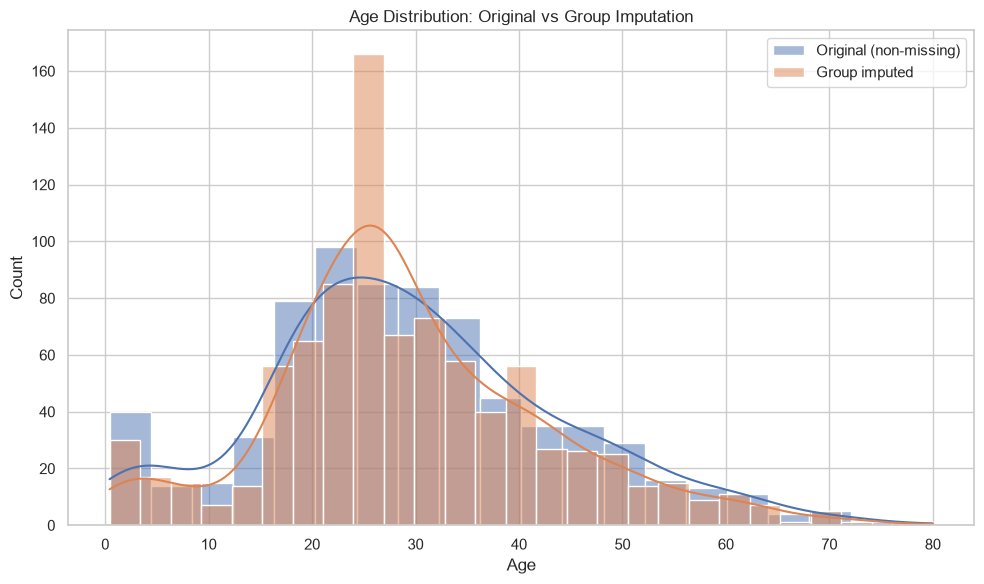

In [48]:
# Compare the original and group-imputed age distributions
plt.figure(figsize=(10, 6))

# Plot histograms
sns.histplot(titanic_df['Age'].dropna(), kde=True, label='Original (non-missing)', alpha=0.5)
sns.histplot(df_group_imputed['Age'], kde=True, label='Group imputed', alpha=0.5)

plt.title('Age Distribution: Original vs Group Imputation')
plt.xlabel('Age')
plt.legend()
plt.tight_layout()
plt.show()


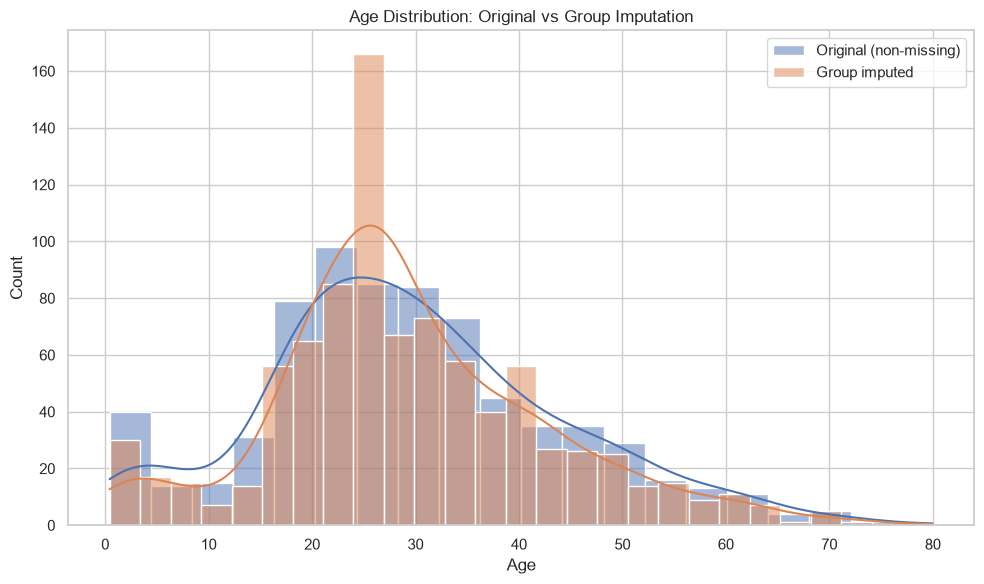

### 5.2 Imputation by KNNImputer (Machine Learning Model)
> KNN will be covered later when we start Machine Learning

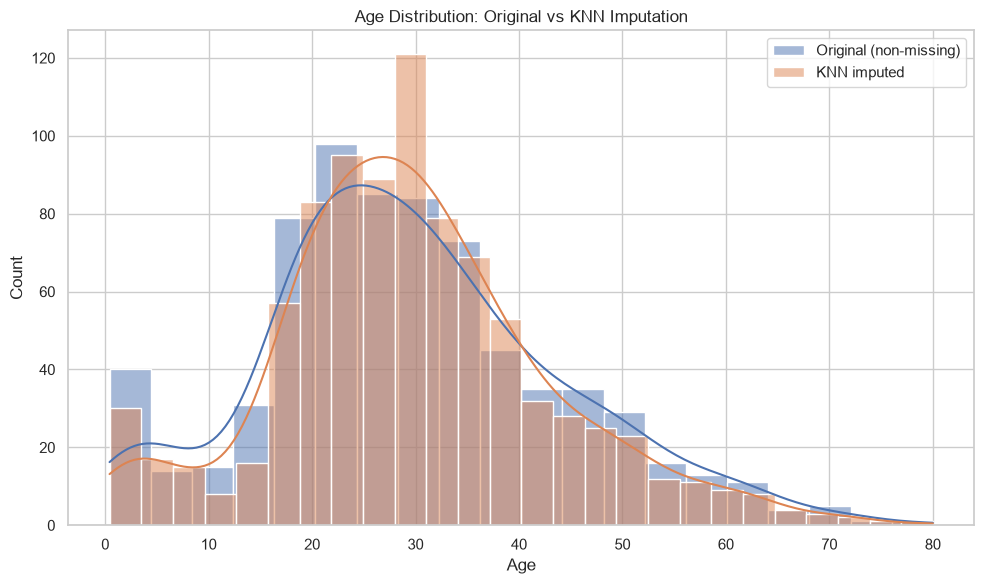

#### 5.2.1 Comparing `Group imputation` vs. `KNN imputation`

- As the two charts show, **KNN produce much better imputation** compared to **group-wise** imputation

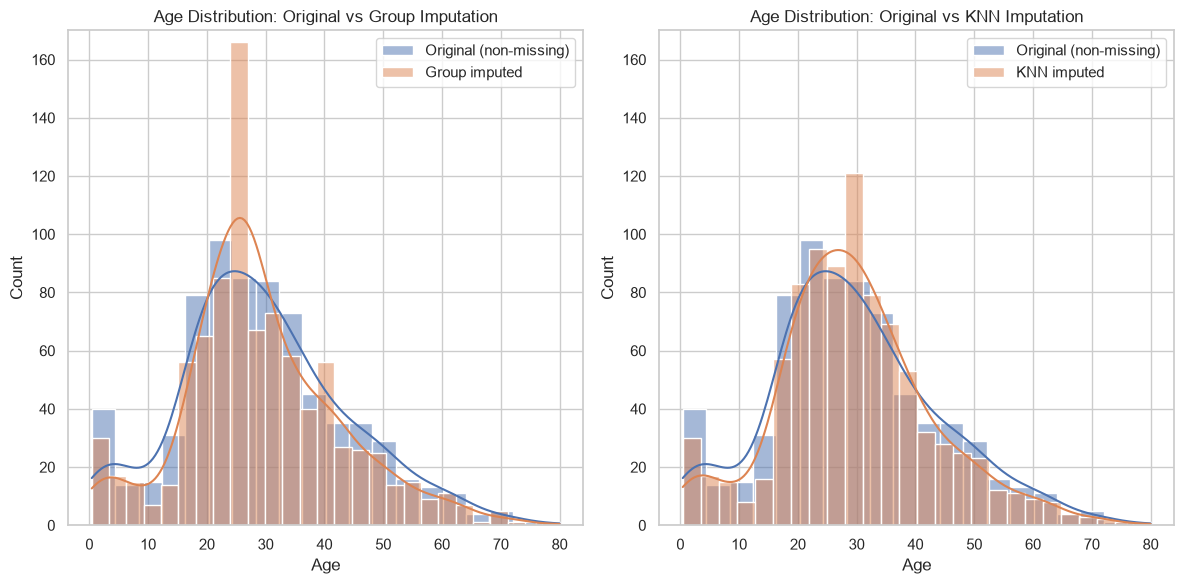


### 5.3 Adding Missing Indicators

Creating indicator variables for missingness can help preserve information about the pattern of missing data.

In [50]:
# Create a copy of the original data set
df_with_indicators = titanic_df.copy()
# Add missing indicators for 'Age' and 'Cabin'
df_with_indicators["Age_missing"]= df_with_indicators["Age"].isnull().astype(int)
df_with_indicators["Cabin_missing"]= df_with_indicators["Cabin"].isnull().astype(int)

# Impute missing values
df_with_indicators["Age"] = df_with_indicators["Age"].fillna(df_with_indicators["Age"].mean())
df_with_indicators["Cabin"] = df_with_indicators["Cabin"].fillna("unkown")

# Check the result
df_with_indicators.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Age_missing,Cabin_missing
0,1,0,3,"Braund, Mr. Owen Harris",male,22.000000,1,0,A/5 21171,7.2500,unkown,S,0,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.000000,1,0,PC 17599,71.2833,C85,C,0,0
2,3,1,3,"Heikkinen, Miss. Laina",female,26.000000,0,0,STON/O2. 3101282,7.9250,unkown,S,0,1
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.000000,1,0,113803,53.1000,C123,S,0,0
4,5,0,3,"Allen, Mr. William Henry",male,35.000000,0,0,373450,8.0500,unkown,S,0,1
5,6,0,3,"Moran, Mr. James",male,29.699118,0,0,330877,8.4583,unkown,Q,1,1
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.000000,0,0,17463,51.8625,E46,S,0,0
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.000000,3,1,349909,21.0750,unkown,S,0,1
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.000000,0,2,347742,11.1333,unkown,S,0,1
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.000000,1,0,237736,30.0708,unkown,C,0,1


# 6. Handling Mixed Data Types

Real-world data sets often contain a mix of numerical and categorical variables. Let's implement a complete missing data handling strategy for the Titanic data set.

In [ ]:
# Create a copy of the original data set
# Examine the data types


In [ ]:
# Implement a complete missing data strategy
# 1. Drop columns with too many missing values
# 2. Handle numerical variables
# Group passengers by class and gender for more accurate imputation
    # Calculate group means
    # Impute missing values with group means
    # For any remaining missing values (rare groups), use overall mean
# 3. Handle categorical variables
# Impute 'Embarked' with mode
# 4. Check if there are any missing values left


# 7. Best Practices and Conclusion

Let's summarize best practices for handling missing data in Python:

### Best Practices for Handling Missing Data

1. **Understand the data**: Always start by exploring the extent and patterns of missingness.
2. **Consider the missingness mechanism**: Is the data MCAR, MAR, or MNAR? This influences your choice of handling method.
3. **Document your approach**: Keep track of how you handled missing data for transparency and reproducibility.
4. **Use appropriate methods for different variables**: Consider the type and importance of each variable.
5. **Create missing indicators**: For key variables, create indicator variables to preserve information about missingness.
6. **Compare different approaches**: Evaluate the impact of different methods on your analysis or model.
7. **Consider domain knowledge**: Incorporate subject matter expertise in your imputation strategy.
8. **Be cautious with deletion methods**: Only use deletion when data is MCAR or the amount of missingness is very small.
9. **Conduct sensitivity analysis**: Test how sensitive your conclusions are to different missing data handling approaches.

# 8. Now You Try

1. Load a data set of your choice (you can use any that we have seen so far, or one of your own) and identify missing values.
2. Visualize the pattern of missingness using `missingno`.
3. Implement at least three different imputation methods.
4. Evaluate and compare the methods based on their effect on your analysis results or model performance.
5. Develop a comprehensive strategy for handling missing data in the data set, taking into account the variable types and missingness patterns.

# 9. Conclusion

In this notebook, we've explored various techniques for handling missing data in Python using pandas and other libraries. We've learned how to identify, visualize, and address missing values using deletion and imputation methods. Remember that there's no one-size-fits-all approach to handling missing data, and the best strategy depends on the specific characteristics of your data set and the goals of your analysis.